In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
import lightgbm as lgb
import shap

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [20]:
df = pd.read_csv('../data/processed.csv')
print(df.shape)
df.head()

(55653, 35)


,id,성별,연령,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,...,치석,흡연여부,BMI,기준_허리둘레,기준_혈압,기준_혈당,기준_트리글리세라이드,기준_HDL,대사증후군_점수,대사증후군_위험군
0,0,여,40,155,60,81.3,1.2,1.0,1.0,1.0,...,1,0,24.973985,False,False,False,False,False,0,0
1,1,여,40,160,60,81.0,0.8,0.6,1.0,1.0,...,1,0,23.437500,False,False,True,False,True,2,0
2,2,남,55,170,60,80.0,0.8,0.8,1.0,1.0,...,0,1,20.761246,False,True,False,True,False,2,0
3,3,남,40,165,70,88.0,1.5,1.5,1.0,1.0,...,1,0,25.711662,False,False,False,True,False,1,0
4,4,여,40,155,60,86.0,1.0,1.0,1.0,1.0,...,0,0,24.973985,True,False,False,False,False,1,0


In [ ]:
# 사용할 피처 / 타겟
target = '흡연여부'

metabolic_cols = ['기준_허리둘레', '기준_혈압', '기준_혈당', '기준_트리글리세라이드', '기준_HDL',
                   '대사증후군_점수', '대사증후군_위험군']

drop_cols = ['id', target] + metabolic_cols
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target].copy()

print("피처 개수:", len(feature_cols))
feature_cols

피처 개수: 26


['성별',
 '연령',
 '신장',
 '체중',
 '허리둘레',
 '시력_좌',
 '시력_우',
 '청력_좌',
 '청력_우',
 '수축기혈압',
 '이완기혈압',
 '공복혈당',
 '총콜레스테롤',
 '트리글리세라이드',
 'HDL콜레스테롤',
 'LDL콜레스테롤',
 '혈색소',
 '요단백',
 '혈청크레아티닌',
 'AST',
 'ALT',
 '감마지티피',
 '구강검사여부',
 '치아우식증',
 '치석',
 'BMI']

In [33]:
X['성별'] = X['성별'].map({'남': 1, '여': 0})
X.head()

,성별,연령,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,...,혈색소,요단백,혈청크레아티닌,AST,ALT,감마지티피,구강검사여부,치아우식증,치석,BMI
0,0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,12.9,1.0,0.7,18.0,19.0,27.0,1,0,1,24.973985
1,0,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,12.7,1.0,0.6,22.0,19.0,18.0,1,0,1,23.437500
2,1,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,15.8,1.0,1.0,21.0,16.0,22.0,1,0,0,20.761246
3,1,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,14.7,1.0,1.0,19.0,26.0,18.0,1,0,1,25.711662
4,0,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,12.5,1.0,0.6,16.0,14.0,22.0,1,0,0,24.973985


In [34]:
X['시력_좌'] = X['시력_좌'].fillna(X['시력_좌'].mean())
X['시력_우'] = X['시력_우'].fillna(X['시력_우'].mean())

X.isnull().sum().sum()

0

In [35]:
# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print("Train 양성 비율:", y_train.mean())
print("Test 양성 비율:", y_test.mean())

(44522, 26) (11131, 26)
Train 양성 비율: 0.3672790979740353
Test 양성 비율: 0.3672625999460965


In [36]:
# LightGBM 모델 학습
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

pos_ratio = y_train.mean()
scale_pos_weight = (1 - pos_ratio) / pos_ratio

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': 42
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=300,
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 30 rounds
[50]	training's auc: 0.86107	valid_1's auc: 0.849972
[100]	training's auc: 0.874603	valid_1's auc: 0.854855
[150]	training's auc: 0.886027	valid_1's auc: 0.857562
[200]	training's auc: 0.895901	valid_1's auc: 0.85953
[250]	training's auc: 0.904278	valid_1's auc: 0.861282
[300]	training's auc: 0.912091	valid_1's auc: 0.863241
Did not meet early stopping. Best iteration is:
[300]	training's auc: 0.912091	valid_1's auc: 0.863241


In [22]:
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7573443536070434
F1 Score: 0.7257589603005381
AUC: 0.8632407772995241

              precision    recall  f1-score   support

           0       0.90      0.69      0.78      7043
           1       0.62      0.87      0.73      4088

    accuracy                           0.76     11131
   macro avg       0.76      0.78      0.75     11131
weighted avg       0.80      0.76      0.76     11131



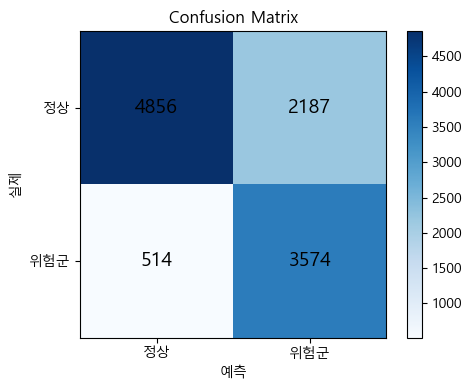

In [23]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['정상', '위험군'])
ax.set_yticklabels(['정상', '위험군'])
ax.set_xlabel('예측')
ax.set_ylabel('실제')
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

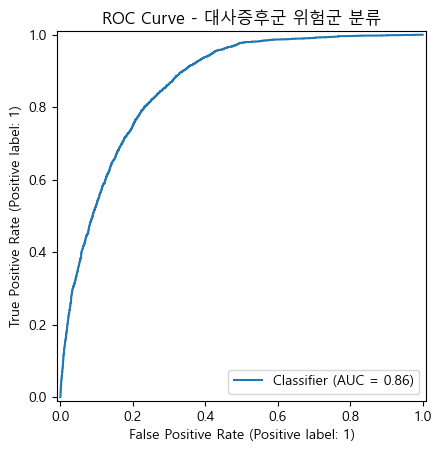

In [24]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title('ROC Curve - 대사증후군 위험군 분류')
plt.savefig('../results/figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

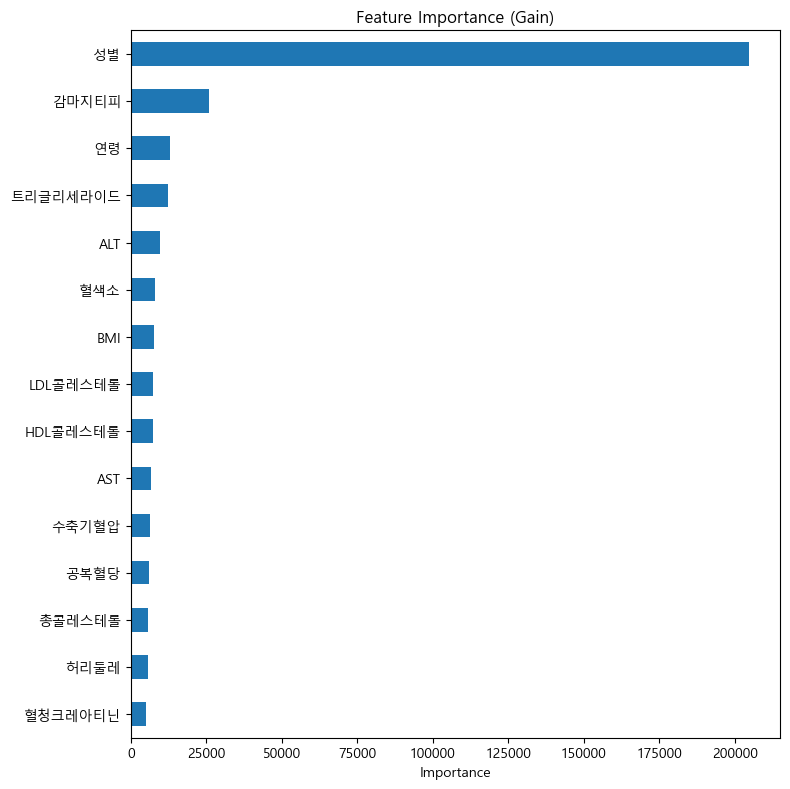

In [25]:
importance = pd.Series(model.feature_importance(importance_type='gain'), index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance (Gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

c:\Users\color\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


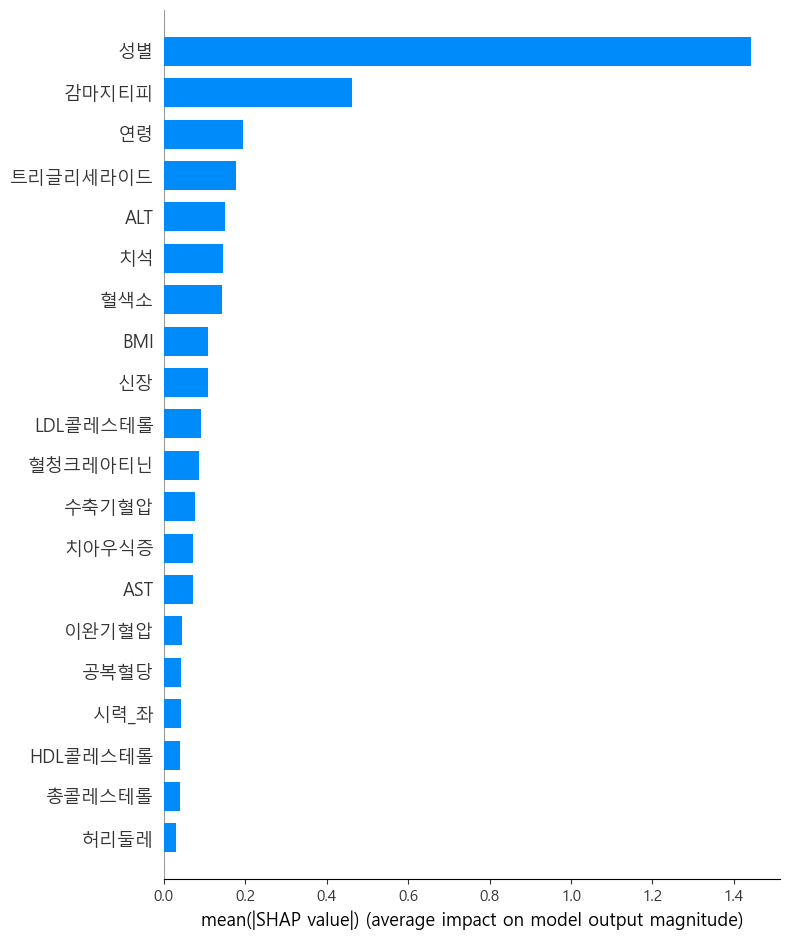

In [37]:
shap.summary_plot(shap_values_plot, X_test, plot_type='bar', show=False)
plt.savefig('../results/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

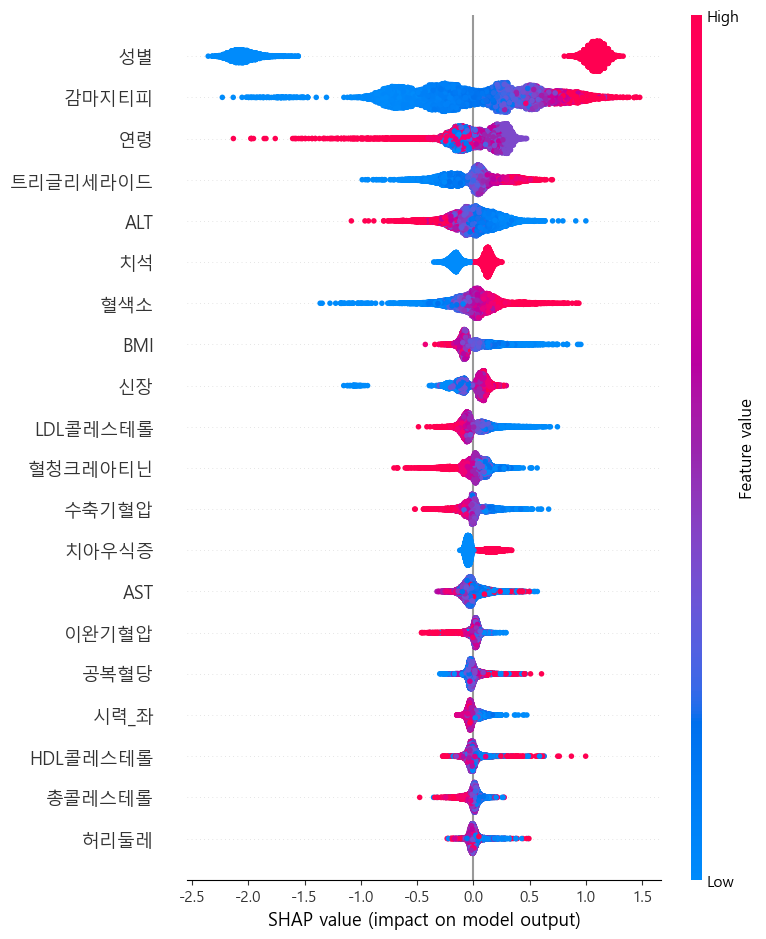

In [38]:

shap.summary_plot(shap_values_plot, X_test, show=False)
plt.savefig('../results/figures/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\color\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\color\AppData\Local\Temp\ipykernel_9808\3221868870.py:11: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig('../results/figures/shap_waterfall_sample.png', dpi=150, bbox_inches='tight')
C:\Users\color\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


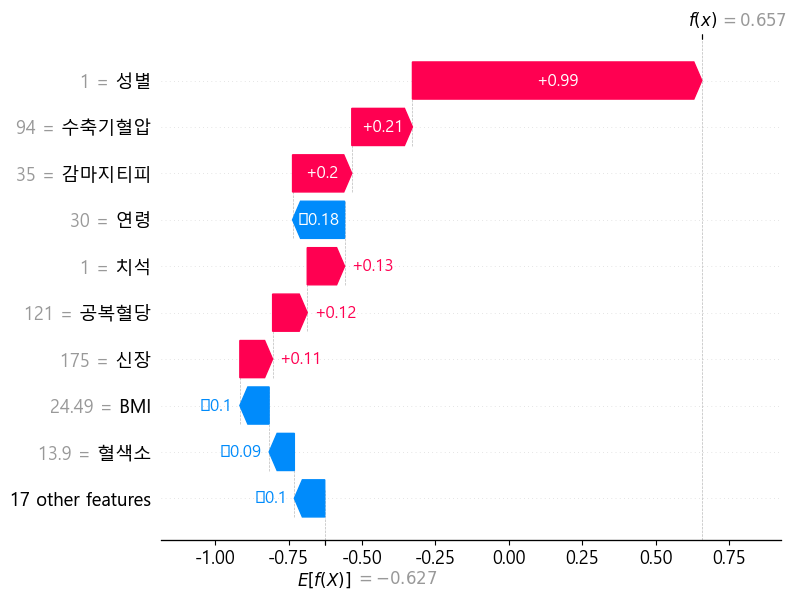

In [28]:
sample_idx = 0  
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_plot[sample_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.atleast_1d(explainer.expected_value)) > 1 else explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.savefig('../results/figures/shap_waterfall_sample.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
def explain_prediction(idx):
    sample = X_test.iloc[idx]
    proba = y_pred_proba[idx]
    actual = y_test.iloc[idx]

    print(f"실제 위험군 여부: {actual} / 예측 확률: {proba:.3f}")
    print()

    shap_row = pd.Series(shap_values_plot[idx], index=feature_cols).sort_values(key=abs, ascending=False)
    print("위험도에 영향을 준 주요 변수 (상위 5개):")
    for feat, val in shap_row.head(5).items():
        direction = "위험 ↑" if val > 0 else "위험 ↓"
        print(f"  - {feat}: {sample[feat]:.2f} ({direction}, SHAP={val:.3f})")

explain_prediction(0)


실제 위험군 여부: 0 / 예측 확률: 0.659

위험도에 영향을 준 주요 변수 (상위 5개):
  - 성별: 1.00 (위험 ↑, SHAP=0.985)
  - 수축기혈압: 94.00 (위험 ↑, SHAP=0.206)
  - 감마지티피: 35.00 (위험 ↑, SHAP=0.202)
  - 연령: 30.00 (위험 ↓, SHAP=-0.177)
  - 치석: 1.00 (위험 ↑, SHAP=0.127)


In [30]:
model.save_model('../results/risk_classifier_lgb.txt')

In [31]:
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_pred_proba)
}

import json
with open('../results/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print(metrics)

{'accuracy': 0.7573443536070434, 'f1': 0.7257589603005381, 'auc': 0.8632407772995241}
